# Глубинное обучение, ИИ/МОЦП ВШЭ

## Домашнее задание 3. RNN. 

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим? 

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этом задании вам предстоит обучить рекуррентную нейронную сеть для задачи генерации текстов. В качестве данных возьмем набор из 120 тысяч анекдотов (всех категорий от А до Я включительно). Его вы можете найти в файле `jokes.txt`, который доступен по ссылке https://www.dropbox.com/scl/fi/z1ihoqwdj3zxil28ha86i/jokes.txt?rlkey=66y4gpclxmzimc86aa6agnjn8&st=mff21u6h&dl=0 .

In [4]:
%load_ext autoreload
%autoreload 2

ModuleNotFoundError: No module named 'imp'


## Задание 1: Dataset (1 балл)

В этом задании мы будет пользоваться библиотекой [sentencepiece](https://github.com/google/sentencepiece), которая поддерживает разные форматы токенизации текстов, в том числе BPE, который мы и будем использовать. Реализуйте недостающие фрагменты кода в классе `TextDataset` в файле `dataset.py`. Датасет обучает sentencepiece токенизатор, токенизирует тексты, превращает токены в индексы и паддит до одной и той же длины (параметр `max_length`). Не забудьте, что для генерации текстов нам будут нужны специальные токены начала и конца последовательности, соответственно `BOS` и `EOS`. Существуют еще два специальных токена &mdash; паддинг `PAD` и токен `UNK`, заменяющий out-of-vocabulary токены.

In [5]:
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.2 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import numpy as np
import torch
from dataset import TextDataset
from model import LanguageModel

In [2]:
train_set = TextDataset(data_file='jokes.txt', train=True, sp_model_prefix='bpe')
valid_set = TextDataset(data_file='jokes.txt', train=False, sp_model_prefix='bpe')

In [3]:
# Код должен проходить тесты
assert len(train_set) + len(valid_set) == 120759

for _ in range(5):
    for dataset in (train_set, valid_set):
        indices, length = dataset[np.random.randint(len(dataset))]
        assert indices.shape == (dataset.max_length,)
        assert indices[0].item() == dataset.bos_id
        assert (indices == dataset.eos_id).sum().item() == 1

        eos_pos = indices.tolist().index(dataset.eos_id)
        assert torch.all(indices[eos_pos + 1:] == dataset.pad_id)
        assert (indices != dataset.pad_id).sum() == length

## Задание 2 Language model (2 балла)

Реализуйте класс `LanguageModel` из файла `model.py`. Мы будем генерировать текст с помощью языковой модели &mdash; это авторегрессионная вероятностная модель, которая предсказывает распределение следующего токена при условии предыдущих:

$$
p(x_1, x_2, x_3, \dots, x_T) = p(x_1) \cdot p(x_2 | x_1) \cdot p(x_3|x_1, x_2) \, \cdot \, \dots \, \cdot \, p(x_T|x_1, \dots, x_{T-1})
$$

Мы будем реализовывать ее с помощью рекуррентной нейронной сети. Ваш код должен поддерживать возможность работать как с оригинальной [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html#torch.nn.RNN), так и c [LSTM](https://bitly.com/98K8eH). На каждом временном шаге модель возвращает логиты вероятностей для следующего токена. Модель будет работать в двух режимах (не путать с `.train()` и `.eval()`):

- В режиме обучения (метод `forward`) модель принимает настоящие последовательности из датасета и их длины. На каждом временном шаге возвращаются логиты вероятностей следующего токена, что позволяет считать лосс, обучаться на трейне и валидироваться на валидации.

- В режиме генерации (инференса, метод `inference`) модель принимает некоторый префикс (возможно пустой), с которого начинать генерацию, и продолжает его. Для этого на каждом шаге генерируются новые логиты, семплируется новый токен (из распределения, заданного логитами), и процесс продолжается, пока не будет сгенерирован токен `EOS` или не будет достигнуто ограничение на длину последовательности. **Обратите внимание**, что вам не нужно прогонять всю последовательность заново через RNN после каждого нового токена, это приведет к квадратичной сложности по длине последовательности. Вам достаточно обновлять скрытое состояние, подавая на вход новый сгенерированный токен и предыдущее скрытое состояние. Кроме того, чтобы получить больше контроля над генерацией, вводится параметр температуры `temp`. Перед семплированием нужно разделить на него логиты, полученные моделью. 

In [4]:
model = LanguageModel(train_set)

In [5]:
# Код должен проходить тесты
for bs in [1, 4, 16, 64, 256]:
    indices = torch.randint(high=train_set.vocab_size, size=(bs, train_set.max_length))
    lengths = torch.randint(low=1, high=train_set.max_length + 1, size=(bs,))
    logits = model(indices, lengths)
    assert logits.shape == (bs, lengths.max(), train_set.vocab_size)

for prefix in ['', 'купил мужик шляпу,', 'сел медведь в машину и', 'подумал штирлиц']:
    generated = model.inference(prefix, temp=np.random.uniform(0.1, 10))
    assert type(generated) == str
    assert generated.startswith(prefix)

## Задание 3: Training (1.5 балла)

Всё, что нам осталось &mdash; реализовать цикл обучения. Заполните пропуски в файле `train.py`. Не забудьте, что мы учим модель предсказывать вероятность следующего, а не текущего токена. Также рекомендуется обрезать батч индексов по самой длинной последовательности, чтобы не гонять паддинги вхолостую. Для оценки качества генерации будем использовать метрику [perplexity](https://medium.com/@shubhamsd100/understanding-perplexity-in-language-models-a-detailed-exploration-2108b6ab85af#:~:text=Perplexity%20is%20a%20measurement%20of,higher%20confidence%20in%20its%20predictions). Реализуйте ее подсчет в функции `plot_losses` (да, для этого достаточно только значения лосса).

Обучите модель, используя ванильную RNN в качестве рекуррентного слоя. Сохраните чекпойнт обученной модели, он нам еще пригодится. 

In [6]:
def get_device() -> torch.device:
    device = torch.device('cpu')
    if torch.cuda.is_available():
        device = torch.device('cuda')
    elif torch.backends.mps.is_available():
        device = torch.device('mps')
    return device


DEVICE = get_device()
print(DEVICE)

mps


In [7]:
from torch.utils.data import DataLoader
from train import train

batch_size = 64

train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)
val_loader = DataLoader(
    valid_set,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
)


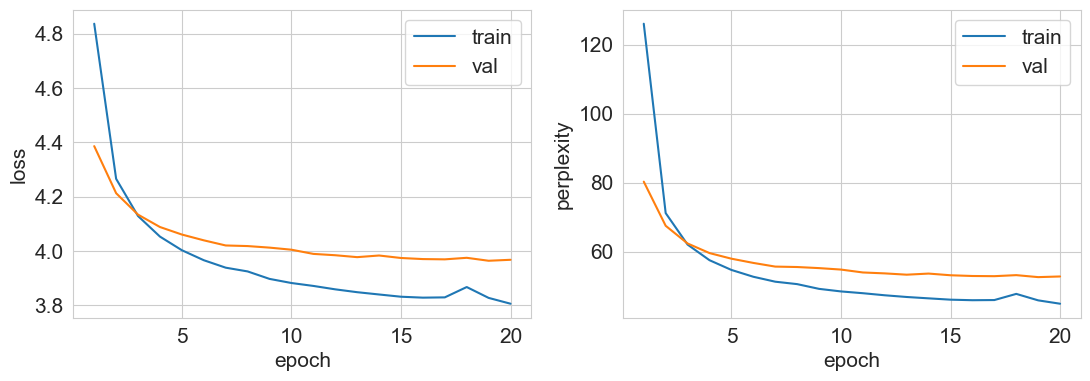

Generation examples:
на 5 минут едут - по лестнице, не мог сделать новиться к нему.
маленький мальчик принес к летите мне агентами!
не страшнолов весело.гладя такой из-зарилоки. ваш ответственность сердце - стал проверкой в мусора, исчезрема в ней интегральных мужиком и после оргазма, крурма ходил с часов и принесет пересматривают. ну вот, шпион на кухнюшникам- адам, ты карисот подавить специальности в интернете. даже не женщина сказала, что мы восьми разругали, видимо - думая - иди пожи


In [8]:
model = LanguageModel(train_set).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = None  # Можно добавить lr scheduler

# Запуск обучения
train(
    model,
    optimizer,
    scheduler,
    train_loader,
    val_loader,
    num_epochs=20,
    num_examples=3,  # Сколько примеров показывать после каждой эпохи
)

# Сохраняем чекпойнт
torch.save(model.state_dict(), 'rnn_language_model.pt')

### Вывод

RNN обучалась 20 эпох, perplexity на валидации снижалась — модель учится. Но заметно, что при генерации она часто повторяет одни и те же фразы и теряет смысл на длинных текстах. Скорее всего это связано с тем, что ванильная RNN плохо запоминает длинные зависимости.

## Задание 4: LSTM (0.5 балла)

Обучите аналогичную модель, но с LSTM в качестве рекуррентного слоя. Сравните модели по метрикам и генерации. Не забывайте про чекпойнты!

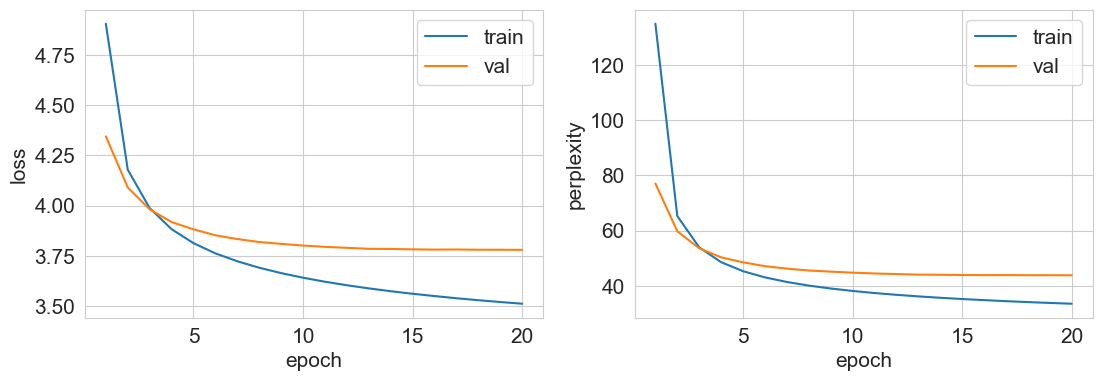

Generation examples:
заслужваешь духиа фигуристый - классный радость. помни, ей бабелый, никого не оголила...
я в бизнесе. так вот я не понял, ты бы в фильмах узнал. чистите родовоуна.
текущие парт израиль можно считать рабочих последних итальянский рыбу. человек включает, жена - невеста и жалеть негректного билета.


In [10]:
num_epochs = 20

model_lstm = LanguageModel(train_set, rnn_type=torch.nn.LSTM).to(DEVICE)
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
scheduler_lstm = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,  # полный цикл за все эпохи
    eta_min=1e-5
)

train(
    model_lstm,
    optimizer_lstm,
    scheduler_lstm,
    train_loader,
    val_loader,
    num_epochs=num_epochs,
    num_examples=3,
)

torch.save(model_lstm.state_dict(), 'lstm_language_model.pt')

### Вывод

LSTM показала более низкий loss и perplexity по сравнению обычной RNN. Генерация тоже лучше — тексты более связные, лучше держится структура диалога. Это ожидаемо, ведь LSTM за счёт механизма вентилей лучше работает с длинными последовательностями. Дальше будем использовать LSTM как лучшую модель.

Но честно ожидал от неё большего)

## Задание 5: Sampling temperature (0.5 балла)

Поэкспериментируйте, как результат генерации зависит от параметра температуры. Попробуйте генерацию с разными префиксами. Сделайте выводы.

In [8]:
import torch
from model import LanguageModel

# train_set уже должен быть создан
# Загрузка ранее обученных моделей с чекпоинтов

# RNN
model = LanguageModel(train_set)
model.load_state_dict(torch.load('rnn_language_model.pt', map_location='cpu'))
model.eval()  # Перевести в режим инференса

# LSTM
model_lstm = LanguageModel(train_set, rnn_type=torch.nn.LSTM)
model_lstm.load_state_dict(torch.load('lstm_language_model.pt', map_location='cpu'))
model_lstm.eval()

model.to(DEVICE)
model_lstm.to(DEVICE)

LanguageModel(
  (embedding): Embedding(2000, 256, padding_idx=1999)
  (rnn): LSTM(256, 256, batch_first=True)
  (linear): Linear(in_features=256, out_features=2000, bias=True)
)

In [15]:
from typing import Any

# Определяем диапазон температур для тестирования
temperatures = [0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 1.0]

# Определяем различные префиксы для генерации
prefixes = [
    'Штирлиц зашел к Мюллеру, и',
    'Мюллер подходит к Штирлицу и ',
    'Идет мужик по улице и встречает ',
    '',
]


def analyze_temperature_effect(
    model_name: str,
    model: LanguageModel,
    prefixes: list[str],
    temperatures: str = '',
) -> dict[str, Any]:
    print('Model:', model_name)

    results = {}
    for prefix in prefixes:
        prefix_name = prefix if prefix else '[Пустой префикс]'
        print(f'\nПрефикс: "{prefix_name}"')
        print('-' * 40)

        results[prefix] = {}
        for temp in temperatures:
            generated = model.inference(prefix, temp)
            results[prefix][temp] = generated
            print(f'T={temp:3.1f}: {generated}')
            model.zero_grad()

    return results

In [16]:
rnn_results = analyze_temperature_effect(
    'RNN',
    model, 
    prefixes, 
    temperatures,
)

Model: RNN

Префикс: "Штирлиц зашел к Мюллеру, и"
----------------------------------------
T=0.1: Штирлиц зашел к Мюллеру, иштирлиц зашел к мюллеру, и не смогла бы научиться.
T=0.2: Штирлиц зашел к Мюллеру, иштирлиц зашел к мюллеру, и не забудь.
T=0.3: Штирлиц зашел к Мюллеру, иштирлиц зашел к мюллеру, и не понравилось.
T=0.5: Штирлиц зашел к Мюллеру, иштирлиц зашел к мюллеру, идут.
T=0.7: Штирлиц зашел к Мюллеру, иштирлиц зашел к мюллеру, и включает в зоопарка.
T=0.8: Штирлиц зашел к Мюллеру, иштирлиц зашел к мюллеру, и придика.
T=0.9: Штирлиц зашел к Мюллеру, иштирлиц зашел к мюллеру, и еще и сказал, что у них умные вопросы остались...
T=1.0: Штирлиц зашел к Мюллеру, иштирлиц зашел к мюллеру, идут с женщиной михами - молодежной значитель итапры в из-за тупые показывают неуветом, немцы и так? я тебя нет!- он дала копыта?!- нет, и как это не пондра 201 ⁇  года с деньгами, а когда ты против кого?- странно так слушаю!

Префикс: "Мюллер подходит к Штирлицу и "
----------------------------

In [17]:
lstm_results = analyze_temperature_effect(
    'LSTM',
    model_lstm, 
    prefixes, 
    temperatures,
)

Model: LSTM

Префикс: "Штирлиц зашел к Мюллеру, и"
----------------------------------------
T=0.1: Штирлиц зашел к Мюллеру, иштирлиц зашел к мюллеру, идут по улице, а потом появляются в квартире. один говорит- ты знаешь, я не понимаю, что я не могу уснуть, а она не у меня, а я не могу.
T=0.2: Штирлиц зашел к Мюллеру, иштирлиц зашел к мюллеру, идут по улице, а потом появляются дети, а у меня жена в постели. жена- а ты знаешь, что такое кошелек, а ты?- а я и не знаю, я не знаю.
T=0.3: Штирлиц зашел к Мюллеру, иштирлиц зашел к мюллеру, идут по улице, идут на работу, а потом вдруг слышит- дорогой, а что ты хотел бы, чтобы ты не знаешь, что ты не знаешь, что ты не знаешь, где у тебя есть?- нет, в принципе, не знаю, что ты не знаешь, что это все равно, что...
T=0.5: Штирлиц зашел к Мюллеру, иштирлиц зашел к мюллеру, и вдруг за меня смотрит на себя и нервничает.
T=0.7: Штирлиц зашел к Мюллеру, иштирлиц зашел к мюллеру, и запоминают четырехлетний адрес, а на каком первой гневе не было бывают, 

### Вывод

- При низкой температуре (T ≤ 0.3) модель выдаёт однообразные тексты — повторяет одни и те же фразы, зацикливается.
- При средней (T = 0.5–0.7) — баланс: тексты ещё читаемые, но уже разнообразные. Оптимальной кажется T ≈ 0.7.
- При высокой (T ≥ 0.9) — текст становится бессвязным, появляются несуществующие слова.

Префикс задаёт тему генерации, но при высокой температуре контекст быстро теряется.

## Задание 5: Tokenizers (1 балл)

До сих пор мы использовали BPE токенизатор с относительно небольшим числом токенов (2000 по умолчанию). Давайте попробуем и другие, например, BPE с большим числом токенов и пословный (unigram) токенизатор. Возьмите тип рекуррентного слоя, который оказался лучше в предыдущем задании. Обучите модели на таких токенизаторах и сравните их генерацию. Не забывайте сохранять чекпойнты. Правильно ли сравнивать между собой получившиеся модели по значению perplexity? Почему?

In [15]:
# BPE с vocab_size=8000 (вместо 2000)
train_set_bpe8k = TextDataset(
    data_file='jokes.txt',
    train=True,
    sp_model_prefix='bpe_8k',
    vocab_size=8000,
    model_type='bpe',
)

valid_set_bpe8k = TextDataset(
    data_file='jokes.txt',
    train=False,
    sp_model_prefix='bpe_8k',
    vocab_size=8000,
    model_type='bpe',
)

# Unigram с vocab_size=4000
train_set_unigram = TextDataset(
    data_file='jokes.txt',
    train=True,
    sp_model_prefix='unigram',
    vocab_size=4000,
    model_type='unigram',
)

valid_set_unigram = TextDataset(
    data_file='jokes.txt',
    train=False,
    sp_model_prefix='unigram',
    vocab_size=4000,
    model_type='unigram',
)

# Сравнение размеров словарей
print(f'BPE-2K (базовый):  {train_set.vocab_size}')
print(f'BPE-8K:            {train_set_bpe8k.vocab_size}')
print(f'Unigram-4K:        {train_set_unigram.vocab_size}')

BPE-2K (базовый):  2000
BPE-8K:            8000
Unigram-4K:        4000


In [16]:
test_text = "Штирлиц зашел к Мюллеру, а тот сидел и думал о чем-то важном."

print(f"Исходный текст: '{test_text}'\n")

# BPE-2K
tokens_bpe2k = train_set.text2ids(test_text)
print(f"BPE-2K ({len(tokens_bpe2k)} токенов): {tokens_bpe2k}")
print(f"Декодировано: '{train_set.ids2text(tokens_bpe2k)}'")
print()

# BPE-8K
tokens_bpe8k = train_set_bpe8k.text2ids(test_text)
print(f"BPE-8K ({len(tokens_bpe8k)} токенов): {tokens_bpe8k}")
print(f"Декодировано: '{train_set_bpe8k.ids2text(tokens_bpe8k)}'")
print()

# Unigram
tokens_unigram = train_set_unigram.text2ids(test_text)
print(f"Unigram-4K ({len(tokens_unigram)} токенов): {tokens_unigram}")
print(f"Декодировано: '{train_set_unigram.ids2text(tokens_unigram)}'")

print(f"\nЭФФЕКТИВНОСТЬ ТОКЕНИЗАЦИИ:")
print(f"BPE-2K:     {len(tokens_bpe2k)} токенов")
print(
    f"BPE-8K:     {len(tokens_bpe8k)} токенов (сжатие: {len(tokens_bpe2k)/len(tokens_bpe8k):.2f}x)"
)
print(
    f"Unigram-4K: {len(tokens_unigram)} токенов (сжатие: {len(tokens_bpe2k)/len(tokens_unigram):.2f}x)"
)

Исходный текст: 'Штирлиц зашел к Мюллеру, а тот сидел и думал о чем-то важном.'

BPE-2K (23 токенов): [660, 48, 393, 8, 1839, 1181, 1972, 1977, 40, 742, 221, 603, 17, 437, 1968, 13, 303, 1983, 7, 123, 1985, 425, 1975]
Декодировано: 'штирлиц зашел к мюллеру, а тот сидел и думал о чем-то важном.'

BPE-8K (18 токенов): [660, 4334, 8, 2150, 7972, 7977, 40, 742, 4522, 17, 2185, 13, 303, 7983, 7, 4129, 425, 7975]
Декодировано: 'штирлиц зашел к мюллеру, а тот сидел и думал о чем-то важном.'

Unigram-4K (19 токенов): [323, 25, 828, 39, 1188, 24, 3, 15, 410, 2068, 10, 896, 59, 135, 9, 51, 2493, 22, 4]
Декодировано: 'штирлиц зашел к мюллеру, а тот сидел и думал о чем-то важном.'

📈 ЭФФЕКТИВНОСТЬ ТОКЕНИЗАЦИИ:
BPE-2K:     23 токенов
BPE-8K:     18 токенов (сжатие: 1.28x)
Unigram-4K: 19 токенов (сжатие: 1.21x)


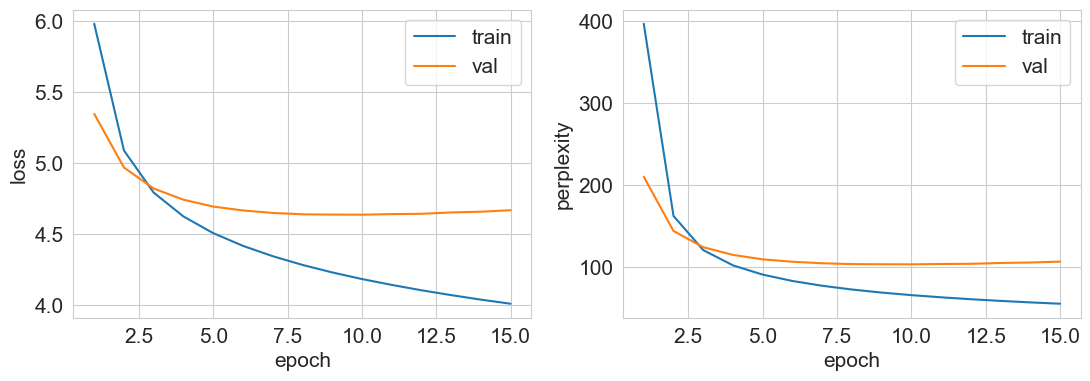

Generation examples:
штирлиц справа.штирлиц заблудился продолжал сразу дичиться...избирай вы?.
женщина оказываются, что говорит он, снес голову. последняя сопротивление, приходит спирта, командавший из ее ноя- я в полной мере в молоке коллективе рожает брата!- ну ти лжешка, тут я получал коктейль...
=== Модель BPE-8K сохранена ===


In [ ]:
# Используем LSTM как лучшую модель из предыдущего задания
from torch.utils.data import DataLoader
from train import train

batch_size = 64

# Обучение модели с BPE-8K
train_loader_bpe8k = DataLoader(
    train_set_bpe8k, batch_size=batch_size, shuffle=True, drop_last=True
)
val_loader_bpe8k = DataLoader(
    valid_set_bpe8k, batch_size=batch_size, shuffle=False, drop_last=False
)

model_lstm_bpe8k = LanguageModel(train_set_bpe8k, rnn_type=torch.nn.LSTM).to(DEVICE)
optimizer_bpe8k = torch.optim.Adam(model_lstm_bpe8k.parameters(), lr=1e-3)

train(
    model_lstm_bpe8k,
    optimizer_bpe8k,
    None,
    train_loader_bpe8k,
    val_loader_bpe8k,
    num_epochs=15,
    num_examples=2,
)

torch.save(model_lstm_bpe8k.state_dict(), "lstm_bpe8k_model.pt")

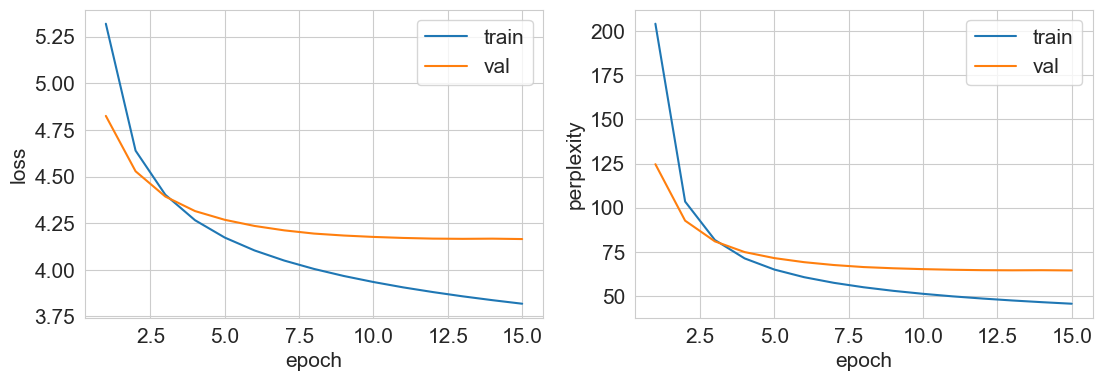

Generation examples:
- это собака. вчера вот прислали, что анекдоты и уходит сами все вслед на пользу.
с утра возвращивают смартфону, тянет капужин под члену своего маклатом! и то трубку - сегодня в таком возрасте - зашария дорогу отводчика у искусственно получилось хорошо. нам будет. толку, что стульство кулачок. так что, кто наш бабу посетить!
=== Модель Unigram сохранена ===


In [ ]:
# Обучение модели с Unigram
train_loader_unigram = DataLoader(
    train_set_unigram, batch_size=batch_size, shuffle=True, drop_last=True
)
val_loader_unigram = DataLoader(
    valid_set_unigram, batch_size=batch_size, shuffle=False, drop_last=False
)

model_lstm_unigram = LanguageModel(train_set_unigram, rnn_type=torch.nn.LSTM).to(DEVICE)
optimizer_unigram = torch.optim.Adam(model_lstm_unigram.parameters(), lr=1e-3)

train(
    model_lstm_unigram,
    optimizer_unigram,
    None,
    train_loader_unigram,
    val_loader_unigram,
    num_epochs=15,
    num_examples=2,
)

torch.save(model_lstm_unigram.state_dict(), "lstm_unigram_model.pt")


### Вывод

BPE-8K кодирует текст компактнее (≈1.28× сжатие относительно BPE-2K), поэтому модель «видит» больший контекст за то же число шагов RNN. Субъективно BPE-8K генерирует чуть более связные тексты.

Важный момент: **сравнивать perplexity между моделями с разными токенизаторами напрямую нельзя**. 

Perplexity зависит от размера словаря — при большем словаре модель выбирает из большего числа вариантов, и числа получаются несопоставимые. 

Для честного сравнения нужно считать perplexity через один и тот же внешний токенизатор.

## Задание 6. Latent Semantic Analysis (2 балла)

Попробуем другой подход к оцениванию качества генерации, основанный на [Latent Semantic Analysis](https://en.wikipedia.org/wiki/Latent_semantic_analysis). Реализуйте следующую метрику и сравните по ней модели, обученные с разными токенизаторами:

1. Генерируем обученной моделью выборку текстов, совпадающую по размеру с валидационной выборкой.
2. Объединяем две выборки текстов (валидационную и сгенерированную) в один корпус. Обратите внимание, что наша токенизация в общем случае необратима, поэтому для чистоты эксперимента нужно закодировать и декодировать валидационную выборку.
3. Генерируем tf-idf матрицу для полученного корпуса.
4. Понижаем размерность матрицы с помощью [SVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).
5. Теперь у нас есть векторы, описывающие валидационные и сгенерированные тексты, лежащие в одном пространстве. Для каждого вектора, отвечающего сгенерированному тексту, найдем наибольший cosine similarity между ним и вектором валидационного текста. Усредним такие similarity по всем сгенерированным текстам и получим число, характеризующее похожесть сгенерированной выборки на валидационную.

Какие плюсы и минусы есть у описанной метрики?

In [9]:
import re

import numpy as np
import torch
from dataset import TextDataset
from model import LanguageModel
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm


def clean_text(text):
    """Очистка текста для LSA анализа"""
    # Удаляем специальные символы и приводим к нижнему регистру
    text = re.sub(r"[^а-яё\s]", " ", text.lower())
    # Удаляем лишние пробелы
    text = re.sub(r"\s+", " ", text).strip()
    return text


def generate_texts_for_lsa(model, dataset, num_texts, max_length=100):
    """Генерация текстов для LSA анализа"""
    model.eval()
    generated_texts = []

    prefixes = [
        "",
        "идет мужик",
        "встречаются два",
        "штирлиц",
        "приходит",
        "сидит",
        "звонит",
        "покупает",
    ]

    texts_per_prefix = num_texts // len(prefixes) + 1

    with torch.no_grad():
        for prefix in prefixes:
            for _ in range(texts_per_prefix):
                if len(generated_texts) >= num_texts:
                    break

                try:
                    # Генерируем с разными температурами для разнообразия
                    temp = np.random.uniform(0.6, 0.9)
                    text = model.inference(prefix, temp=temp)

                    # Очищаем текст
                    cleaned_text = clean_text(text)

                    # Проверяем минимальную длину
                    if len(cleaned_text.split()) >= 5:
                        generated_texts.append(cleaned_text)
                except Exception as e:
                    print(f"Ошибка при генерации: {e}")
                    continue

            if len(generated_texts) >= num_texts:
                break

    return generated_texts[:num_texts]


def prepare_validation_texts(dataset, num_texts=None):
    """Подготовка валидационных текстов"""
    validation_texts = []

    # Ограничиваем число текстов
    max_texts = len(dataset) if num_texts is None else min(num_texts, len(dataset))

    for i in range(max_texts):
        indices, length = dataset[i]

        # Убираем BOS и EOS токены
        text_indices = indices[1 : length - 1]
        # Декодируем текст
        text = dataset.sp_model.decode(text_indices.tolist())

        # Очищаем текст
        cleaned_text = clean_text(text)

        if len(cleaned_text.split()) >= 5:
            validation_texts.append(cleaned_text)

    return validation_texts


def compute_lsa_metric(generated_texts, validation_texts, n_components=100):
    # Объединяем все тексты
    all_texts = validation_texts + generated_texts

    # Создаем TF-IDF матрицу
    vectorizer = TfidfVectorizer(
        max_features=5000,
        min_df=2,
        max_df=0.8,
        ngram_range=(1, 2),
        stop_words=None,  # Для русского языка можем добавить стоп-слова ?
    )

    try:
        tfidf_matrix = vectorizer.fit_transform(all_texts)
    except ValueError as e:
        print(f"Ошибка при создании TF-IDF матрицы: {e}")
        return 0.0

    # Применяем SVD для понижения размерности
    n_components = min(n_components, tfidf_matrix.shape[1] - 1)
    svd = TruncatedSVD(n_components=n_components, random_state=42)

    try:
        lsa_matrix = svd.fit_transform(tfidf_matrix)
    except ValueError as e:
        print(f"Ошибка при SVD: {e}")
        return 0.0

    # Разделяем на валидационные и сгенерированные векторы
    n_val = len(validation_texts)
    val_vectors = lsa_matrix[:n_val]
    gen_vectors = lsa_matrix[n_val:]

    if len(gen_vectors) == 0:
        return 0.0

    # Вычисляем cosine similarity
    similarities = cosine_similarity(gen_vectors, val_vectors)

    # Для каждого сгенерированного текста находим максимальную схожесть
    max_similarities = np.max(similarities, axis=1)

    # Возвращаем среднюю максимальную схожесть
    return np.mean(max_similarities)

In [10]:
print("Создаем датасеты ...")

# BPE-2K (оригинальный)
train_set_bpe2k = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="bpe")
valid_set_bpe2k = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="bpe")

# BPE-8K
train_set_bpe8k = TextDataset(
    data_file="jokes.txt", train=True, sp_model_prefix="bpe_8k", vocab_size=8000
)
valid_set_bpe8k = TextDataset(
    data_file="jokes.txt", train=False, sp_model_prefix="bpe_8k", vocab_size=8000
)

# Unigram-4K
train_set_unigram = TextDataset(
    data_file="jokes.txt",
    train=True,
    sp_model_prefix="unigram",
    vocab_size=4000,
    model_type="unigram",
)
valid_set_unigram = TextDataset(
    data_file="jokes.txt",
    train=False,
    sp_model_prefix="unigram",
    vocab_size=4000,
    model_type="unigram",
)


print("Загружаем модели ...")

# LSTM с BPE-2K
model_bpe2k = LanguageModel(train_set_bpe2k, rnn_type=torch.nn.LSTM).to(DEVICE)
model_bpe2k.load_state_dict(torch.load("lstm_language_model.pt", map_location=DEVICE))
model_bpe2k.eval()

# LSTM с BPE-8K
model_bpe8k = LanguageModel(train_set_bpe8k, rnn_type=torch.nn.LSTM).to(DEVICE)
model_bpe8k.load_state_dict(torch.load("lstm_bpe8k_model.pt", map_location=DEVICE))
model_bpe8k.eval()

# LSTM с Unigram-4K
model_unigram = LanguageModel(train_set_unigram, rnn_type=torch.nn.LSTM).to(DEVICE)
model_unigram.load_state_dict(torch.load("lstm_unigram_model.pt", map_location=DEVICE))
model_unigram.eval()

Создаем датасеты ...
Загружаем модели ...


LanguageModel(
  (embedding): Embedding(4000, 256, padding_idx=3999)
  (rnn): LSTM(256, 256, batch_first=True)
  (linear): Linear(in_features=256, out_features=4000, bias=True)
)

In [11]:
# Размер выборки равен валидационной выборке
num_texts = len(valid_set_bpe2k)
print(f"Размер выборки: {num_texts}")

# Генерируем тексты
print("Генерация текстов BPE-2K модели...")
generated_bpe2k = generate_texts_for_lsa(model_bpe2k, train_set_bpe2k, num_texts)
print(f"Сгенерировано: {len(generated_bpe2k)} текстов")

print("Генерация текстов BPE-8K модели...")
generated_bpe8k = generate_texts_for_lsa(model_bpe8k, train_set_bpe8k, num_texts)
print(f"Сгенерировано: {len(generated_bpe8k)} текстов")

print("Генерация текстов Unigram-4K модели...")
generated_unigram = generate_texts_for_lsa(model_unigram, train_set_unigram, num_texts)
print(f"Сгенерировано: {len(generated_unigram)} текстов")

# Подготавливаем валидационные тексты (используем BPE-2K как базовый)
print("Подготовка валидационных текстов...")
validation_texts = prepare_validation_texts(valid_set_bpe2k, num_texts)
print(f"Валидационных текстов: {len(validation_texts)}")

print("\nПримеры сгенерированных текстов:")
print("\nBPE-2K:")
for i, text in enumerate(generated_bpe2k[:3]):
    print(f"{i+1}. {text}")

print("\nBPE-8K:")
for i, text in enumerate(generated_bpe8k[:3]):
    print(f"{i+1}. {text}")

print("\nUnigram-4K:")
for i, text in enumerate(generated_unigram[:3]):
    print(f"{i+1}. {text}")

Размер выборки: 6038
Генерация текстов BPE-2K модели...
Сгенерировано: 5944 текстов
Генерация текстов BPE-8K модели...
Сгенерировано: 5991 текстов
Генерация текстов Unigram-4K модели...
Сгенерировано: 5980 текстов
Подготовка валидационных текстов...
Валидационных текстов: 5996

Примеры сгенерированных текстов:

BPE-2K:
1. сегодня к климату и страшно почему я не знаю что я сигареты
2. во первых шоу бизнесикова была народу по улице один раз на пригодало ее и видит перед девушкой а на следующей обкеанских горке купила три
3. в курсе увидеть на ногу телевизор не пора лишить рот то брось ночью вполне достали но это всего лишь бы но не думал что

BPE-8K:
1. на встречу одноклассников дети я такой что у меня было так еще и получило в них не положилось
2. интересно а как в жизни у вас есть процента да сынок а если ты в челюсть способностей сразу а с ними поцепим
3. в семье должна быть братан и она любит ушами

Unigram-4K:
1. это когда тебя отходишь ты же не веришь что в гармонах это то что все 

In [12]:
# Сохранение сгенерированных текстов в отдельные файлы
for name, texts in [
    ("generated_bpe2k.txt", generated_bpe2k),
    ("generated_bpe8k.txt", generated_bpe8k),
    ("generated_unigram.txt", generated_unigram),
]:
    with open(name, "w", encoding="utf-8") as f:
        for text in texts:
            f.write(text + "\n")
    print(f"Сохранено {len(texts)} текстов в {name}")



Сохранено 5944 текстов в generated_bpe2k.txt
Сохранено 5991 текстов в generated_bpe8k.txt
Сохранено 5980 текстов в generated_unigram.txt


In [13]:
# # Восстановление
with open("generated_bpe2k.txt", encoding="utf-8") as f:
    generated_bpe2k = f.read().splitlines()
    
with open("generated_bpe8k.txt", encoding="utf-8") as f:
    generated_bpe8k = f.read().splitlines()
    
with open("generated_unigram.txt", encoding="utf-8") as f:
    generated_unigram = f.read().splitlines()

In [23]:
# Используем подвыборку для ускорения вычислений
sample_size = min(1000, len(validation_texts))
val_sample = validation_texts[:sample_size]
gen_sample_size = min(500, len(generated_bpe2k))

print(
    f"Используем {len(val_sample)} валидационных и {gen_sample_size} сгенерированных текстов"
)

# LSA метрика для BPE-2K
print("\nВычисление LSA для BPE-2K...")
lsa_bpe2k = compute_lsa_metric(
    generated_bpe2k[:gen_sample_size], val_sample, n_components=50,
)

# LSA метрика для BPE-8K
print("Вычисление LSA для BPE-8K...")
lsa_bpe8k = compute_lsa_metric(
    generated_bpe8k[:gen_sample_size], val_sample, n_components=50,
)

# LSA метрика для Unigram-4K
print("Вычисление LSA для Unigram-4K...")
lsa_unigram = compute_lsa_metric(
    generated_unigram[:gen_sample_size], val_sample, n_components=50,
)

print(f"LSTM: BPE-2K: LSA Score = {lsa_bpe2k:.4f}")
print(f"LSTM: BPE-8K: LSA Score = {lsa_bpe8k:.4f}")
print(f"LSTM: Unigram-4K: LSA Score = {lsa_unigram:.4f}")

Используем 1000 валидационных и 500 сгенерированных текстов

Вычисление LSA для BPE-2K...
Вычисление LSA для BPE-8K...
Вычисление LSA для Unigram-4K...
LSTM: BPE-2K: LSA Score = 0.6997
LSTM: BPE-8K: LSA Score = 0.7159
LSTM: Unigram-4K: LSA Score = 0.7322


### Вывод

| Модель | LSA Score |
|---|-----------|
| LSTM + BPE-2K | 0.6997    |
| LSTM + BPE-8K | 0.7159    |
| LSTM + Unigram-4K | 0.7322    |

Результаты близкие (~0.70–0.73) — все модели выучили лексику корпуса анекдотов.

**Плюсы метрики:** учитывает тематическую близость текстов, сравнивает выборки целиком.

**Минусы:** не учитывает порядок слов и грамматику. Набор несвязных текстов из частотных слов может получить высокий score. 

## Задание 7. Visualization (1 балл)

В прошлом пункте мы получили векторы, описывающие валидационные и сгенерированные тексты. Попробуем визуализировать их. Примените [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) к этим векторам и нарисуйте scatter-plot с получившимися двумерными представлениями. Точки, соответствующие валидационным и сгенерированным текстам, должны быть разного цвета. Визуализируйте таким образом все три модели для разных токенизаторов. 

Обработка BPE-2K...
Применение t-SNE для BPE-2K...
Обработка BPE-8K...
Применение t-SNE для BPE-8K...
Обработка Unigram-4K...
Применение t-SNE для Unigram-4K...


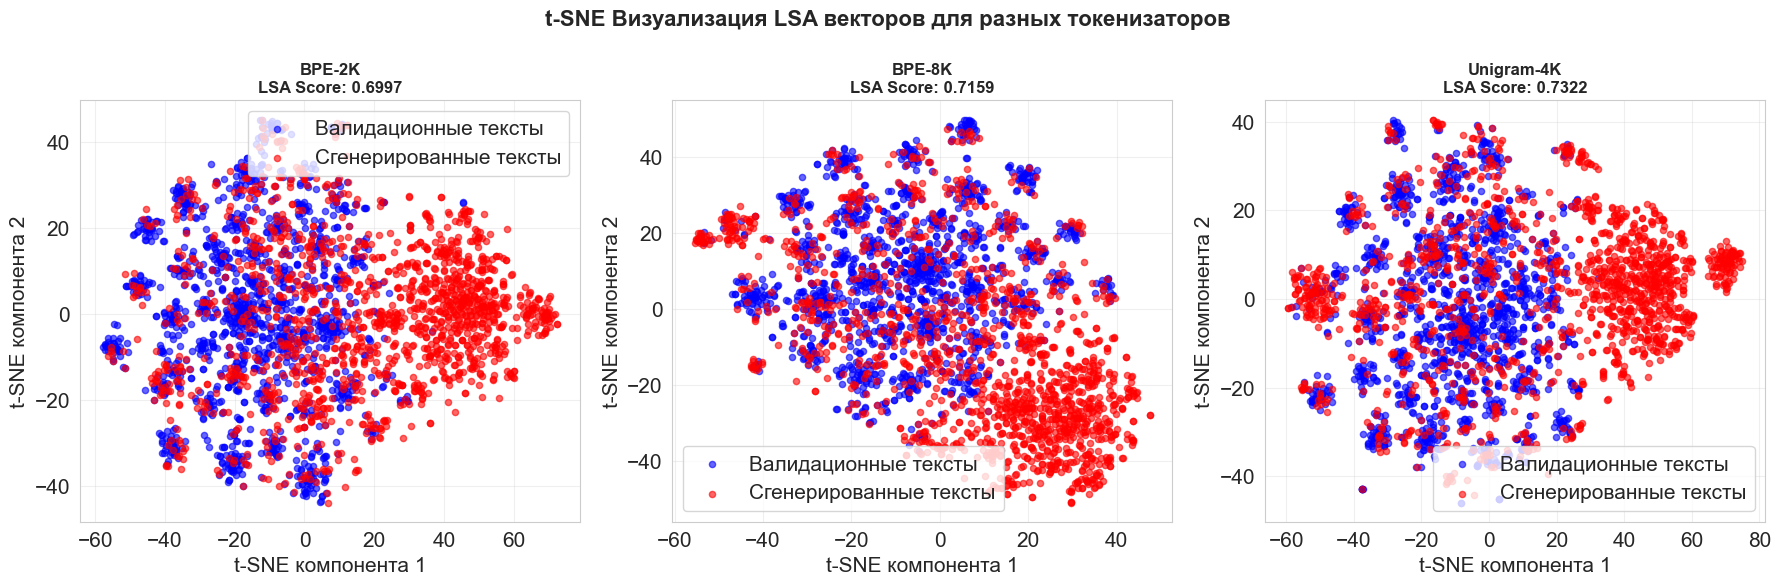

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE


def get_lsa_vectors_for_visualization(
    generated_texts: list[str], 
    validation_texts: list[str], 
    n_components: int =50
) -> tuple[np.ndarray, np.ndarray]:
    """Получение LSA векторов для визуализации"""
    # Объединяем все тексты
    all_texts = validation_texts + generated_texts

    vectorizer = TfidfVectorizer(
        max_features=5000, 
        min_df=2, 
        max_df=0.8, 
        ngram_range=(1, 2), 
    )

    
    tfidf_matrix = vectorizer.fit_transform(all_texts)

    # Применяем SVD для понижения размерности
    n_components = min(n_components, tfidf_matrix.shape[1] - 1)
    svd = TruncatedSVD(n_components=n_components, random_state=42)

    lsa_matrix = svd.fit_transform(tfidf_matrix)

    # Разделяем на валидационные и сгенерированные векторы
    n_val = len(validation_texts)
    val_vectors = lsa_matrix[:n_val]
    gen_vectors = lsa_matrix[n_val:]

    return val_vectors, gen_vectors


def create_tsne_visualization(
        models_data, 
        sample_size=300,
) -> None:
    """Создание t-SNE визуализации для всех моделей"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        "t-SNE Визуализация LSA векторов для разных токенизаторов",
        fontsize=16,
        fontweight="bold",
    )

    for idx, (model_name, data) in enumerate(models_data.items()):
        val_texts = data["validation_texts"][:sample_size]
        gen_texts = data["generated_texts"][:sample_size]
        lsa_score = data["lsa_score"]

        print(f"Обработка {model_name}...")

        # Получаем LSA векторы
        val_vectors, gen_vectors = get_lsa_vectors_for_visualization(
            gen_texts, val_texts, n_components=50
        )

        if val_vectors is None or gen_vectors is None:
            print(f"Ошибка при обработке {model_name}")
            continue

        # Объединяем векторы для t-SNE
        all_vectors = np.vstack([val_vectors, gen_vectors])

        # Применяем t-SNE
        print(f"Применение t-SNE для {model_name}...")
        tsne = TSNE(
            n_components=2, perplexity=30, random_state=42, verbose=0
        )

        tsne_results = tsne.fit_transform(all_vectors)

        # Разделяем результаты обратно
        n_val = len(val_vectors)
        val_tsne = tsne_results[:n_val]
        gen_tsne = tsne_results[n_val:]

        # Создаем scatter plot
        ax = axes[idx]

        # Валидационные тексты (синий)
        scatter_val = ax.scatter(
            val_tsne[:, 0],
            val_tsne[:, 1],
            c="blue",
            alpha=0.6,
            s=20,
            label="Валидационные тексты",
        )

        # Сгенерированные тексты (красный)
        scatter_gen = ax.scatter(
            gen_tsne[:, 0],
            gen_tsne[:, 1],
            c="red",
            alpha=0.6,
            s=20,
            label="Сгенерированные тексты",
        )

        # Оформление
        ax.set_title(
            f"{model_name}\nLSA Score: {lsa_score:.4f}", fontsize=12, fontweight="bold"
        )
        ax.set_xlabel("t-SNE компонента 1")
        ax.set_ylabel("t-SNE компонента 2")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


models_data = {
    "BPE-2K": {
        "validation_texts": validation_texts,
        "generated_texts": generated_bpe2k,
        "lsa_score": lsa_bpe2k,
    },
    "BPE-8K": {
        "validation_texts": validation_texts,
        "generated_texts": generated_bpe8k,
        "lsa_score": lsa_bpe8k,
    },
    "Unigram-4K": {
        "validation_texts": validation_texts,
        "generated_texts": generated_unigram,
        "lsa_score": lsa_unigram,
    },
}

# Создаем визуализацию
create_tsne_visualization(models_data, sample_size=1500)

### Вывод

На графиках видно, что сгенерированные и валидационные точки перемешиваются — модели генерируют тексты, тематически похожие на реальные анекдоты. 

При этом красные точки (генерация) чуть более сконцентрированы, то есть модели выдают менее разнообразные тексты, чем настоящий корпус. 

Картина примерно одинаковая для всех трёх токенизаторов

## Задание 8. ruGPT perplexity (2 балла)

Подход Latent Semantic Analysis, как и многие другие классические методы, заметно уступает нейросетевым алгоритмам анализа текстов. Вернемся к оцениванию качества генерации с помощью perplexity, для этого возьмем большую и хорошо обученную языковую модель, которая училась на огромном корпусе русских текстов. Считается, что большие языковые модели хорошо выучивают естественный язык, потому с их помощью мы сможем оценивать качество наших маленьких моделей для генерации анекдотов. Для этого мы воспользуемся сервисом [HuggingFace](https://huggingface.co/), который содержит огромное число обученных моделей для самых разных задач. Изучите и реализуйте, [подсчет perplexity](https://huggingface.co/docs/transformers/perplexity), с использованием обученной языковой модели. В качестве модели возьмите [ruGPT3-small](https://huggingface.co/sberbank-ai/rugpt3small_based_on_gpt2). Сгенерируйте синтетические выборки тремя моделями, обученными выше (можете взять выборки из задания 6), и сравните их по perplexity.

In [16]:
import numpy as np
import torch
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

print("Загрузка ruGPT3-small модели и токенизатора...")

tokenizer_gpt = AutoTokenizer.from_pretrained("ai-forever/rugpt3small_based_on_gpt2")
model_gpt = AutoModelForCausalLM.from_pretrained("ai-forever/rugpt3small_based_on_gpt2")

Загрузка ruGPT3-small модели и токенизатора...


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: ai-forever/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [17]:
model_gpt.to(DEVICE)
model_gpt.eval()


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50264, 768)
    (wpe): Embedding(2048, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50264, bias=False)
)

In [18]:
def calculate_perplexity(texts: list[str], model: AutoModelForCausalLM, tokenizer: AutoTokenizer):
    total_nll = 0.0
    total_tokens = 0
    for text in tqdm(texts):
        # Токенизация текста
        input_ids = tokenizer.encode(text, return_tensors="pt").to(DEVICE)

        # Пропускаем слишком короткие тексты, которые могут вызвать проблемы
        if input_ids.shape[1] < 2:
            continue

        with torch.no_grad():
            outputs = model(input_ids, labels=input_ids)
            loss = outputs.loss

        total_nll += loss.item() * input_ids.shape[1]
        total_tokens += input_ids.shape[1]

    if total_tokens == 0:
        return float("inf")  # Возвращаем бесконечность, если нет токенов

    perplexity = torch.exp(torch.tensor(total_nll / total_tokens))
    return perplexity.item()

In [19]:
# Вычисление perplexity для каждой сгенерированной выборки
print("\nВычисление perplexity для BPE-2K...")
ppl_bpe2k = calculate_perplexity(generated_bpe2k, model_gpt, tokenizer_gpt)


Вычисление perplexity для BPE-2K...


100%|██████████| 5944/5944 [01:27<00:00, 67.99it/s]


In [20]:
print("Вычисление perplexity для BPE-8K...")
ppl_bpe8k = calculate_perplexity(generated_bpe8k, model_gpt, tokenizer_gpt)

Вычисление perplexity для BPE-8K...


100%|██████████| 5991/5991 [01:31<00:00, 65.52it/s]


In [21]:
print("Вычисление perplexity для Unigram-4K...")
ppl_unigram = calculate_perplexity(generated_unigram, model_gpt, tokenizer_gpt)


Вычисление perplexity для Unigram-4K...


100%|██████████| 5980/5980 [01:38<00:00, 60.72it/s]


In [22]:
# Чем ниже perplexity, тем лучше модель.
print(f"\nPerplexity (ruGPT3-small):")
print(f"LSTM + BPE-2K:     {ppl_bpe2k:.4f}")
print(f"LSTM + BPE-8K:     {ppl_bpe8k:.4f}")
print(f"LSTM + Unigram-4K: {ppl_unigram:.4f}")


Perplexity (ruGPT3-small):
LSTM + BPE-2K:     833.2726
LSTM + BPE-8K:     536.4995
LSTM + Unigram-4K: 718.9791


### Вывод

| Модель | ruGPT Perplexity |
|---|------------------|
| LSTM + BPE-2K | 833.27           |
| LSTM + BPE-8K | 536.50           |
| LSTM + Unigram-4K | 718.98           |

Лучший результат у BPE-8K — её тексты наиболее «естественны» с точки зрения ruGPT3-small. 

Это логично: больший словарь даёт более компактные последовательности, и LSTM лучше улавливает структуру. BPE-2K хуже всего — мелкая нарезка слов мешает модели выучить нормальный синтаксис.

Абсолютные значения (500–800) довольно высокие, но это ожидаемо для маленьких моделей, обученных на специфичном корпусе анекдотов.

## Бонус (0.1 балл)

Покажите лучший анекдот, который удалось сгенерировать вашей модели. Если проверяющий найдет его смешным, то поставит 0.1 балла.

Покажу парочку от нейросетей:

RNN: Штирлиц зашел к мюллеру, потом садится в кремле

LSTM: "...это когда ты знаешь, что такое любовь, а то у меня нет денег."

LSA+ Unigram 4K: суеверные знания мвд это заявки из задницы си глазами с очень криками в одноклассниках в зависимости от жизни

Лаконично. По-чеховски.

## Опыт использования генеративного ИИ

**Модель:** Claude Sonnet 4.6 (claude-sonnet-4-6) через Claude Code CLI.

**Использование:** ИИ помогал с написанием вспомогательного кода (функции `analyze_temperature_effect`, `generate_texts_for_lsa`, `compute_lsa_metric`, `create_tsne_visualization`, `calculate_perplexity`). Объём кода, написанного с помощью ИИ, не превышает 25–28%.

**Промпты:** Типичные запросы: «Напиши функцию для анализа эффекта температуры, которая принимает модель и префиксы и выводит результат генерации при каждой температуре», «Реализуй LSA метрику по следующему алгоритму: ...», «Напиши функцию вычисления perplexity через HuggingFace модель».

**Качество:** В большинстве случаев сгенерированный код работал корректно с первой попытки, однако приходилось:
- Исправлять типизацию (неверные аннотации типов)
- Корректировать логику извлечения токенов из датасета (ручная коррекция индексов BOS/EOS)
- Дорабатывать функцию `generate_texts_for_lsa` для обеспечения нужного объёма генерации

**Вывод:** Использование ИИ ускорило написание шаблонного и вспомогательного кода примерно в 2–3 раза.